In [2]:
import pandas as pd
from keras.models import Sequential
from keras.layers import Dense
from keras.wrappers.scikit_learn import KerasClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from keras.models import Model

Using TensorFlow backend.


In [3]:
df = pd.read_csv("/home/mddo/stage/M2S4/output/FY/diploid_/diploid_0/df/normal_KNN_removed.csv")
dataset = df.values
X = dataset[:,0:7].astype(float)
Y = dataset[:,8]
print(X)

[[5.49132948e-02 3.95885556e-02 1.62162162e-01 ... 6.05095541e-02
  2.80659747e+00 1.68789809e-01]
 [3.17919075e-02 4.09715619e-02 2.70270270e-01 ... 4.33070866e-02
  2.02196562e+00 5.74803150e-01]
 [2.89017341e-03 1.72875789e-04 0.00000000e+00 ... 2.76243094e-03
  1.33049287e-01 5.49723757e-01]
 ...
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 1.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 1.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  4.17406565e-02 1.00000000e+00]]


In [4]:
# encode class values as integers
encoder = LabelEncoder()
encoder.fit(Y)
encoded_Y = encoder.transform(Y)


In [5]:
# baseline model
# create model
model = Sequential()
model.add(Dense(1024, input_dim=7, activation='relu'))
model.add(Dense(512, activation='relu'))
model.add(Dense(256, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
# Compile model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['mae', 'acc'])
# evaluate baseline model with standardized dataset
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_1 (Dense)              (None, 1024)              8192      
_________________________________________________________________
dense_2 (Dense)              (None, 512)               524800    
_________________________________________________________________
dense_3 (Dense)              (None, 256)               131328    
_________________________________________________________________
dense_4 (Dense)              (None, 128)               32896     
_________________________________________________________________
dense_5 (Dense)              (None, 64)                8256      
_________________________________________________________________
dense_6 (Dense)              (None, 1)                 65        
Total params: 705,537
Trainable params: 705,537
Non-trainable params: 0
________________________________________________

In [68]:
model.fit(X, encoded_Y, epochs=1000, batch_size=10)

ms/step - loss: 0.0269 - mae: 0.0175 - acc: 0.9870
Epoch 494/1000
5755/5755 [==============================] - 10s 2ms/step - loss: 0.0351 - mae: 0.0205 - acc: 0.9849
Epoch 495/1000
5755/5755 [==============================] - 9s 2ms/step - loss: 0.0329 - mae: 0.0200 - acc: 0.9861
Epoch 496/1000
5755/5755 [==============================] - 10s 2ms/step - loss: 0.0269 - mae: 0.0182 - acc: 0.9868
Epoch 497/1000
5755/5755 [==============================] - 11s 2ms/step - loss: 0.0277 - mae: 0.0177 - acc: 0.9859
Epoch 498/1000
5755/5755 [==============================] - 10s 2ms/step - loss: 0.0278 - mae: 0.0180 - acc: 0.9858
Epoch 499/1000
5755/5755 [==============================] - 10s 2ms/step - loss: 0.0315 - mae: 0.0199 - acc: 0.9854
Epoch 500/1000
5755/5755 [==============================] - 10s 2ms/step - loss: 0.0278 - mae: 0.0179 - acc: 0.9868
Epoch 501/1000
5755/5755 [==============================] - 10s 2ms/step - loss: 0.0419 - mae: 0.0191 - acc: 0.9866
Epoch 502/1000
5755/57

In [6]:
test_df = pd.read_csv("/home/mddo/stage/M2S4/output/CCD/diploid_/diploid_0/df/normal_KNN_removed.csv")
dataset_test = test_df.values
X_test = dataset_test[:,0:7].astype(float)

In [7]:
# make class predictions with the model
predictions = model.predict_classes(X_test)
predictions_df = pd.DataFrame(predictions)
predictions_df = predictions_df.replace({1:"non_ess", 0 : "ess"})
test_df["predictions"] = predictions_df

In [8]:
print(test_df)

hits_count  reads_count  hits_count_pro   orf_len  insertion_index  \
0       0.069930     0.018663        0.348837  0.017981         0.095541   
1       0.002331     0.000024        0.232558  0.013895         0.003937   
2       0.004662     0.000266        0.023256  0.021251         0.005525   
3       0.041958     0.006503        0.232558  0.012056         0.079295   
4       0.067599     0.007857        0.139535  0.117899         0.016283   
...          ...          ...             ...       ...              ...   
5750    0.100233     0.021249        0.000000  0.079281         0.035420   
5751    0.000000     0.000000        0.000000  0.055442         0.000000   
5752    0.000000     0.000000        0.000000  0.017573         0.000000   
5753    0.000000     0.000000        0.000000  0.207601         0.000000   
5754    0.000000     0.000000        0.000000  0.029424         0.000000   

            NI       HFI        orf    label predictions  
0     2.978830  0.261146    YAL069

In [9]:
from sklearn.metrics import precision_recall_fscore_support
precision_recall_fscore = precision_recall_fscore_support(test_df["label"], test_df["predictions"],average = "binary", pos_label="ess")
print(precision_recall_fscore)

(0.28328173374613, 0.6443661971830986, 0.39354838709677414, None)


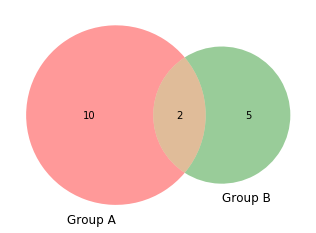

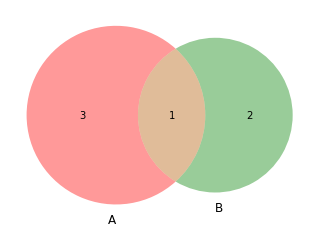

In [9]:
import matplotlib.pyplot as plt
import matplotlib_venn
import pandas as pd
 
# First way to call the 2 group Venn diagram:
venn2(subsets = (10, 5, 2), set_labels = ('Group A', 'Group B'))
plt.show()
 
# Second way
venn2([set(['A', 'B', 'C', 'D']), set(['D', 'E', 'F'])])
plt.show()

In [ ]:
fy_prediction_file = "/home/mddo/stage/M2S4/output/FY/predictions/test/normal_KNN_0/predictions_forest_16_5_13_1019_92.0_100.0.csv"
ccd_prediction_file = "/home/mddo/stage/M2S4/output/CCD/predictions/test/normal_KNN_0/predictions_forest_12_5_15_1275_92.0_93.0.csv"
cpg_prediction_file = "/home/mddo/stage/M2S4/output/CPG/predictions/test/normal_KNN_0/predictions_forest_24_4_15_1456_91.0_93.0.csv"
cnt_prediction_file = "/home/mddo/stage/M2S4/output/CNT/predictions/test/normal_KNN_0/predictions_forest_13_5_18_1492_92.0_91.0.csv"
sigma_prediction_file = "/home/mddo/stage/M2S4/output/Sigma/predictions/test/normal_KNN_0/predictions_forest_11_7_17_1302_93.0_93.0.csv"
chm_prediction_file = "/home/mddo/stage/M2S4/output/CHM/predictions/test/normal_KNN_0/predictions_forest_24_6_11_1381_91.0_90.0.csv"

fy_df = pd.read_csv(fy_prediction_file)
fy_TP_label = fy_df.loc[(fy_df["label"] == "ess") & (fy_df["label"] == fy_df["predictions"])]



















